In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv("../bench_io.csv")
df.head()

,lib,sample_rate,dtype,duration,channels,n_samples,file_size_bytes,load_mean_ms,load_median_ms,load_std_ms,load_min_ms,load_p90_ms,save_mean_ms,save_median_ms,save_std_ms,save_min_ms,save_p90_ms,error
0,audio_samples,8000,i16,1.0,1,8000,16000,0.0047,0.0041,0.0036,0.0040,0.0050,0.0034,0.0028,0.0031,0.0027,0.0036,NaN
1,librosa,8000,i16,1.0,1,8000,16000,0.0230,0.0208,0.0125,0.0195,0.0249,0.0184,0.0167,0.0123,0.0158,0.0183,NaN
2,wave,8000,i16,1.0,1,8000,16000,0.0067,0.0059,0.0059,0.0056,0.0063,0.0071,0.0060,0.0070,0.0055,0.0066,NaN
3,scipy,8000,i16,1.0,1,8000,16000,0.0087,0.0075,0.0068,0.0071,0.0085,0.0089,0.0075,0.0087,0.0071,0.0095,NaN
4,torchaudio,8000,i16,1.0,1,8000,16000,0.6289,0.6016,0.0879,0.5713,0.6808,0.0336,0.0279,0.0210,0.0273,0.0434,NaN


In [2]:
# ---------------------------------------------------------------------------
# Data preparation
# ---------------------------------------------------------------------------

# Coerce numeric columns (stored as strings when empty)
time_cols = [c for c in df.columns if c.endswith("_ms")]
df[time_cols] = df[time_cols].apply(pd.to_numeric, errors="coerce")

# Drop rows where both load and save are missing (unsupported combos)
df_valid = df.dropna(subset=["load_mean_ms", "save_mean_ms"], how="all").copy()

# Build long-form table: one row per (config, lib, operation)
df_load = df_valid[
    ["lib", "sample_rate", "dtype", "duration", "channels",
     "load_mean_ms", "load_std_ms"]
].rename(columns={"load_mean_ms": "mean_ms", "load_std_ms": "std_ms"})
df_load["operation"] = "load"

df_save = df_valid[
    ["lib", "sample_rate", "dtype", "duration", "channels",
     "save_mean_ms", "save_std_ms"]
].rename(columns={"save_mean_ms": "mean_ms", "save_std_ms": "std_ms"})
df_save["operation"] = "save"

df_long = pd.concat([df_load, df_save], ignore_index=True)
df_long["channels_label"] = df_long["channels"].map({1: "mono", 2: "stereo"})
df_long["sr_label"] = df_long["sample_rate"].astype(str) + " Hz"

# Consistent library order across all plots
LIB_ORDER = ["audio_samples", "librosa", "wave", "scipy", "torchaudio"]
LIB_PALETTE = {
    "audio_samples": "#2ca02c",
    "librosa":       "#1f77b4",
    "wave":          "#ff7f0e",
    "scipy":         "#9467bd",
    "torchaudio":    "#d62728",
}
OP_PALETTE = {"load": "#4C72B0", "save": "#DD8452"}

print(f"Rows in long-form table: {len(df_long)}")
df_long.head(10)

Rows in long-form table: 720


,lib,sample_rate,dtype,duration,channels,mean_ms,std_ms,operation,channels_label,sr_label
0,audio_samples,8000,i16,1.0,1,0.0047,0.0036,load,mono,8000 Hz
1,librosa,8000,i16,1.0,1,0.0230,0.0125,load,mono,8000 Hz
2,wave,8000,i16,1.0,1,0.0067,0.0059,load,mono,8000 Hz
3,scipy,8000,i16,1.0,1,0.0087,0.0068,load,mono,8000 Hz
4,torchaudio,8000,i16,1.0,1,0.6289,0.0879,load,mono,8000 Hz
5,audio_samples,8000,i16,1.0,2,0.0058,0.0048,load,stereo,8000 Hz
6,librosa,8000,i16,1.0,2,0.0229,0.0131,load,stereo,8000 Hz
7,wave,8000,i16,1.0,2,0.0073,0.0058,load,stereo,8000 Hz
8,scipy,8000,i16,1.0,2,0.0099,0.0073,load,stereo,8000 Hz
9,torchaudio,8000,i16,1.0,2,1.0311,0.0470,load,stereo,8000 Hz


In [3]:
# ---------------------------------------------------------------------------
# Helper: one FacetGrid bar chart for a given (dtype, channels, operation)
# Rows = sample rate, Cols = duration
# ---------------------------------------------------------------------------

def plot_io_bars(dtype: str, channels: int, operation: str) -> None:
    ch_label = "mono" if channels == 1 else "stereo"
    subset = df_long[
        (df_long["dtype"] == dtype)
        & (df_long["channels"] == channels)
        & (df_long["operation"] == operation)
        & (df_long["lib"] != "torchaudio")
    ].copy()

    sr_order  = [f"{sr} Hz" for sr in sorted(df_long["sample_rate"].unique())]
    dur_order = sorted(df_long["duration"].unique())

    g = sns.FacetGrid(
        subset,
        row="sr_label", col="duration",
        row_order=sr_order, col_order=dur_order,
        height=2.8, aspect=1.15,
        sharey=False,   # each subplot has its own y-scale for readability
        margin_titles=True,
    )

    def _barplot(data, **kwargs):
        ax = plt.gca()
        libs_present = [l for l in LIB_ORDER if l in data["lib"].values]
        vals  = {row["lib"]: row["mean_ms"] for _, row in data.iterrows()}
        stds  = {row["lib"]: row["std_ms"]  for _, row in data.iterrows()}
        x_pos = np.arange(len(libs_present))
        colors = [LIB_PALETTE[l] for l in libs_present]
        bars = ax.bar(
            x_pos,
            [vals.get(l, np.nan) for l in libs_present],
            # yerr=[stds.get(l, 0.0) for l in libs_present],
            color=colors,
            width=0.6,
            # capsize=3,
            # error_kw={"elinewidth": 0.8, "alpha": 0.7},
        )
        ax.set_xticks(x_pos)
        ax.set_xticklabels(libs_present, rotation=35, ha="right", fontsize=7)
        ax.yaxis.set_major_formatter(
            ticker.FuncFormatter(lambda v, _: f"{v:.3g}")
        )

    g.map_dataframe(_barplot)

    g.set_titles(
        row_template="{row_name}",
        col_template="{col_name:.0f}s",
        size=8,
    )
    g.set_axis_labels("", "Time (ms)")

    g.figure.suptitle(
        f"I/O {operation} — {dtype}  {ch_label}  (mean ± std, ms)",
        fontsize=12, fontweight="bold", y=1.01,
    )
    g.figure.tight_layout()
    plt.show()

## Load times

One grid per `(dtype × channels)` combination.  
Rows = sample rate, columns = duration, bars = library.  
Y-axis is **not** shared across subplots so small differences at low sample rates remain visible.

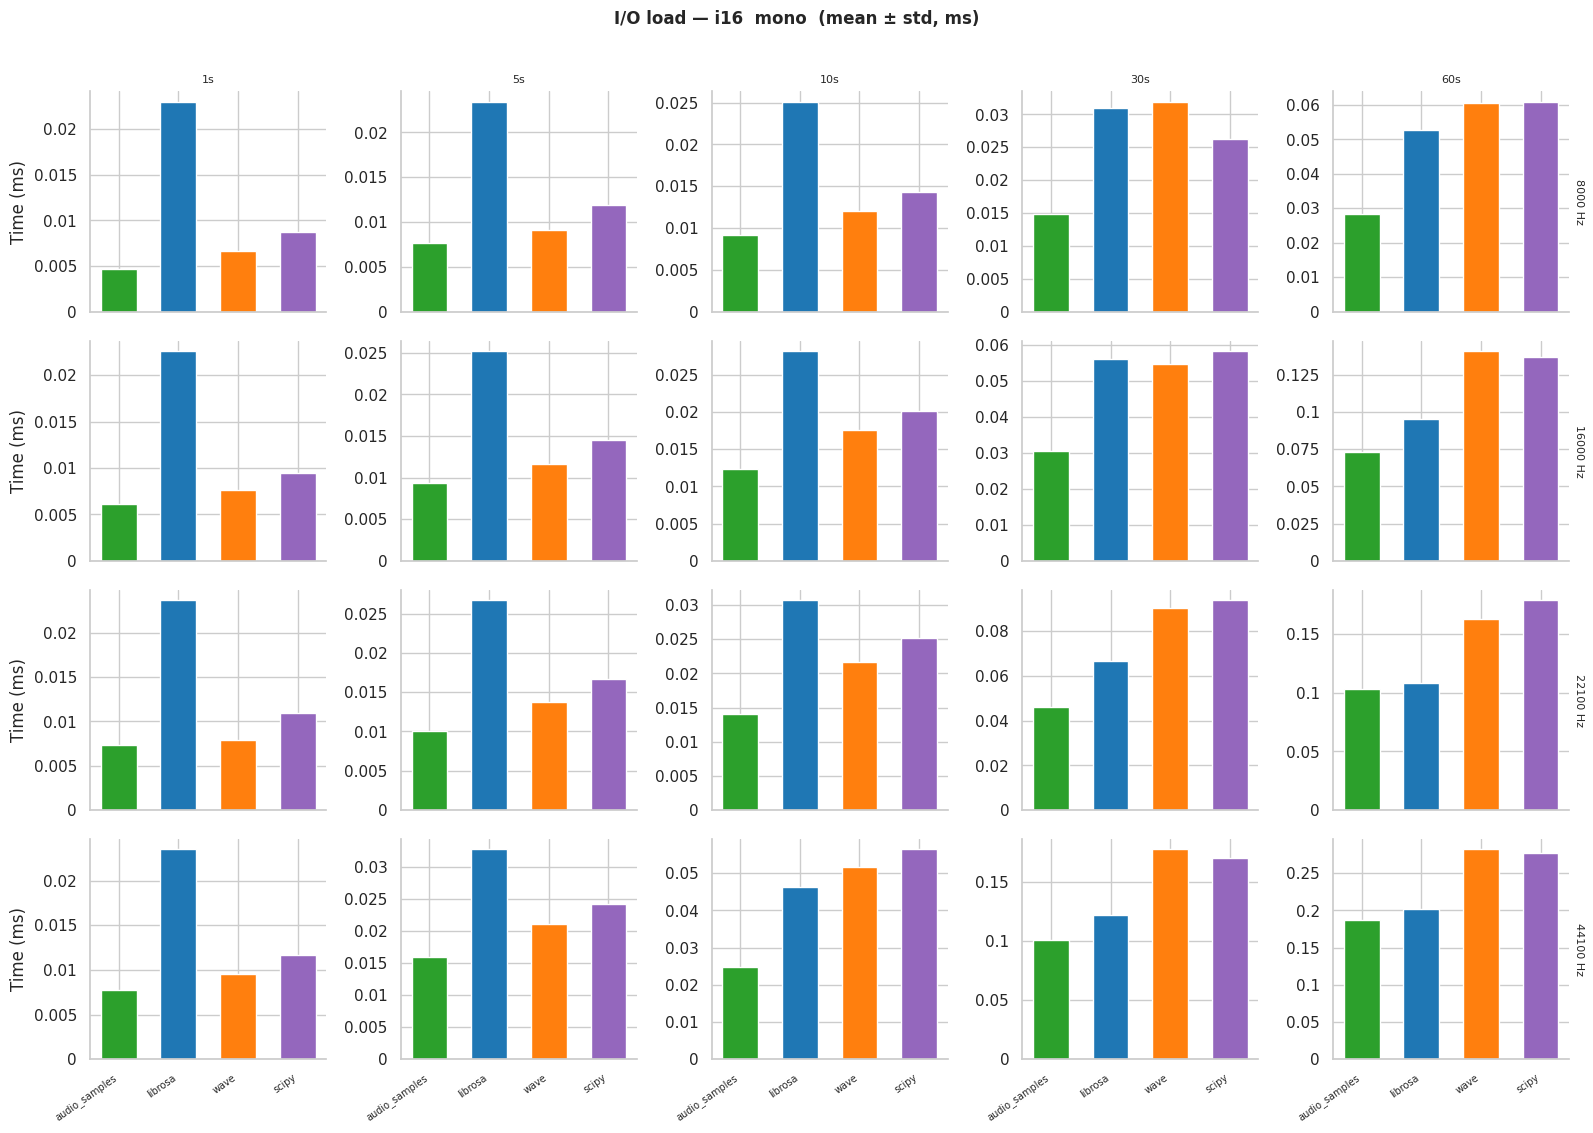

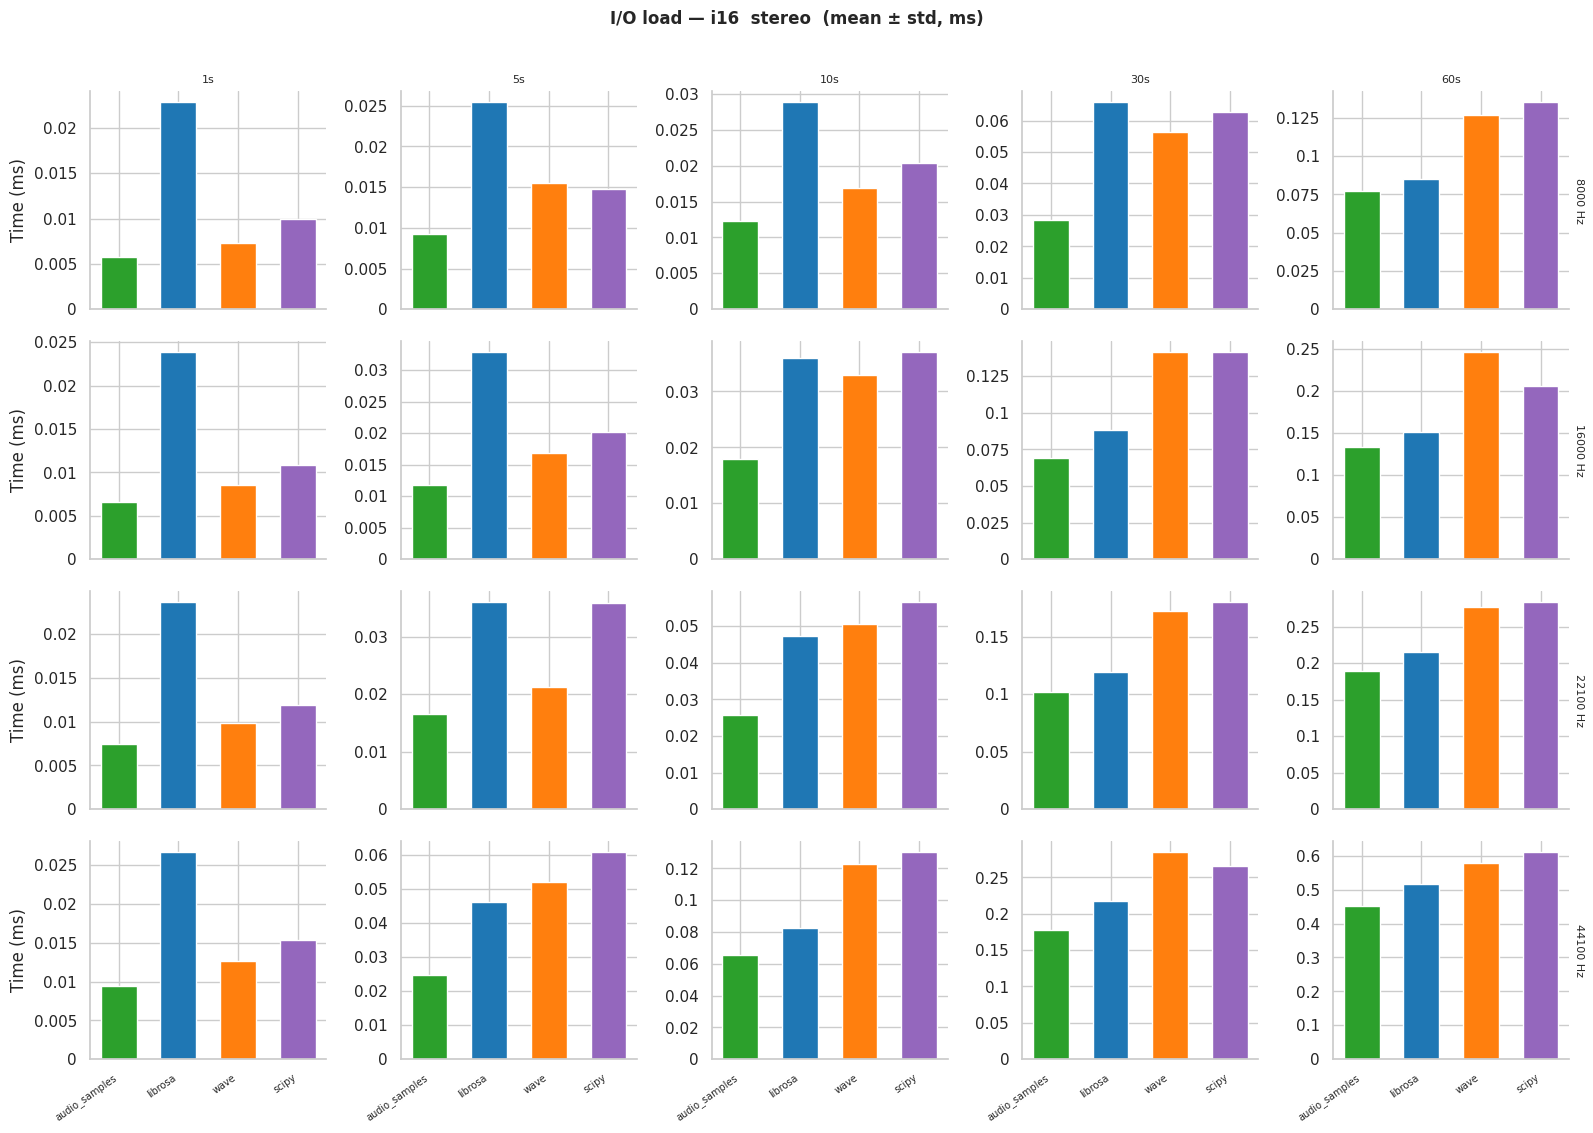

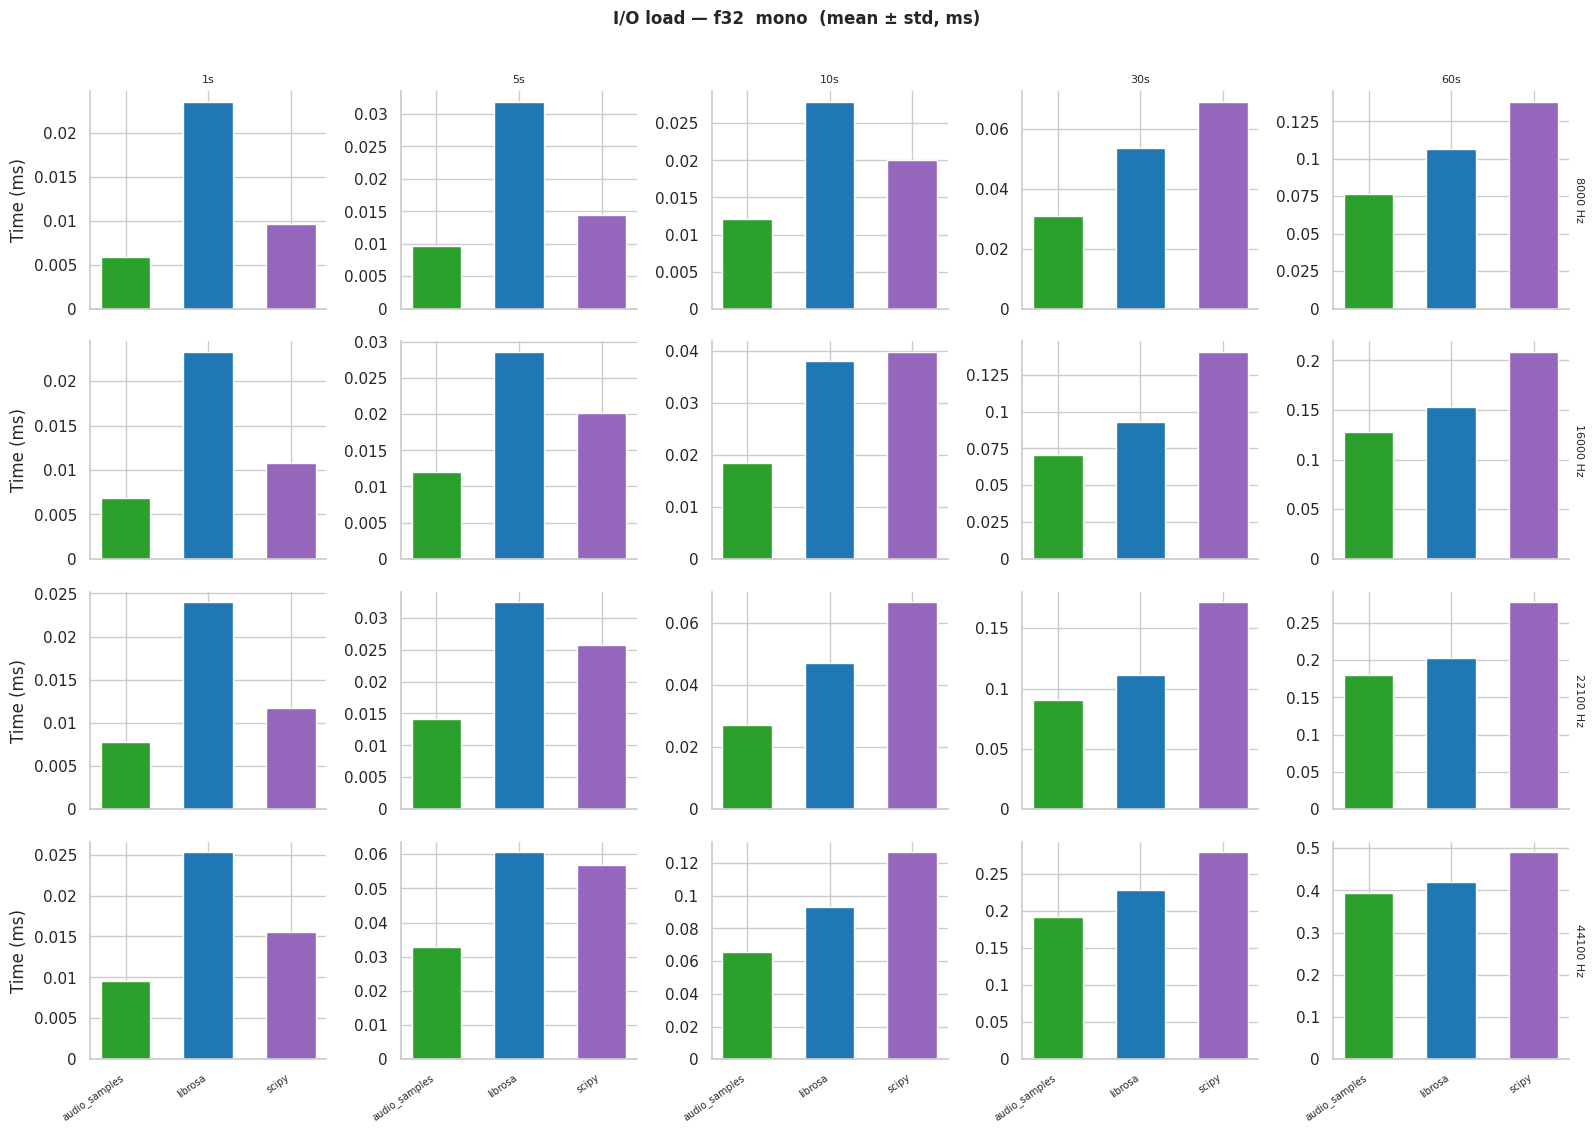

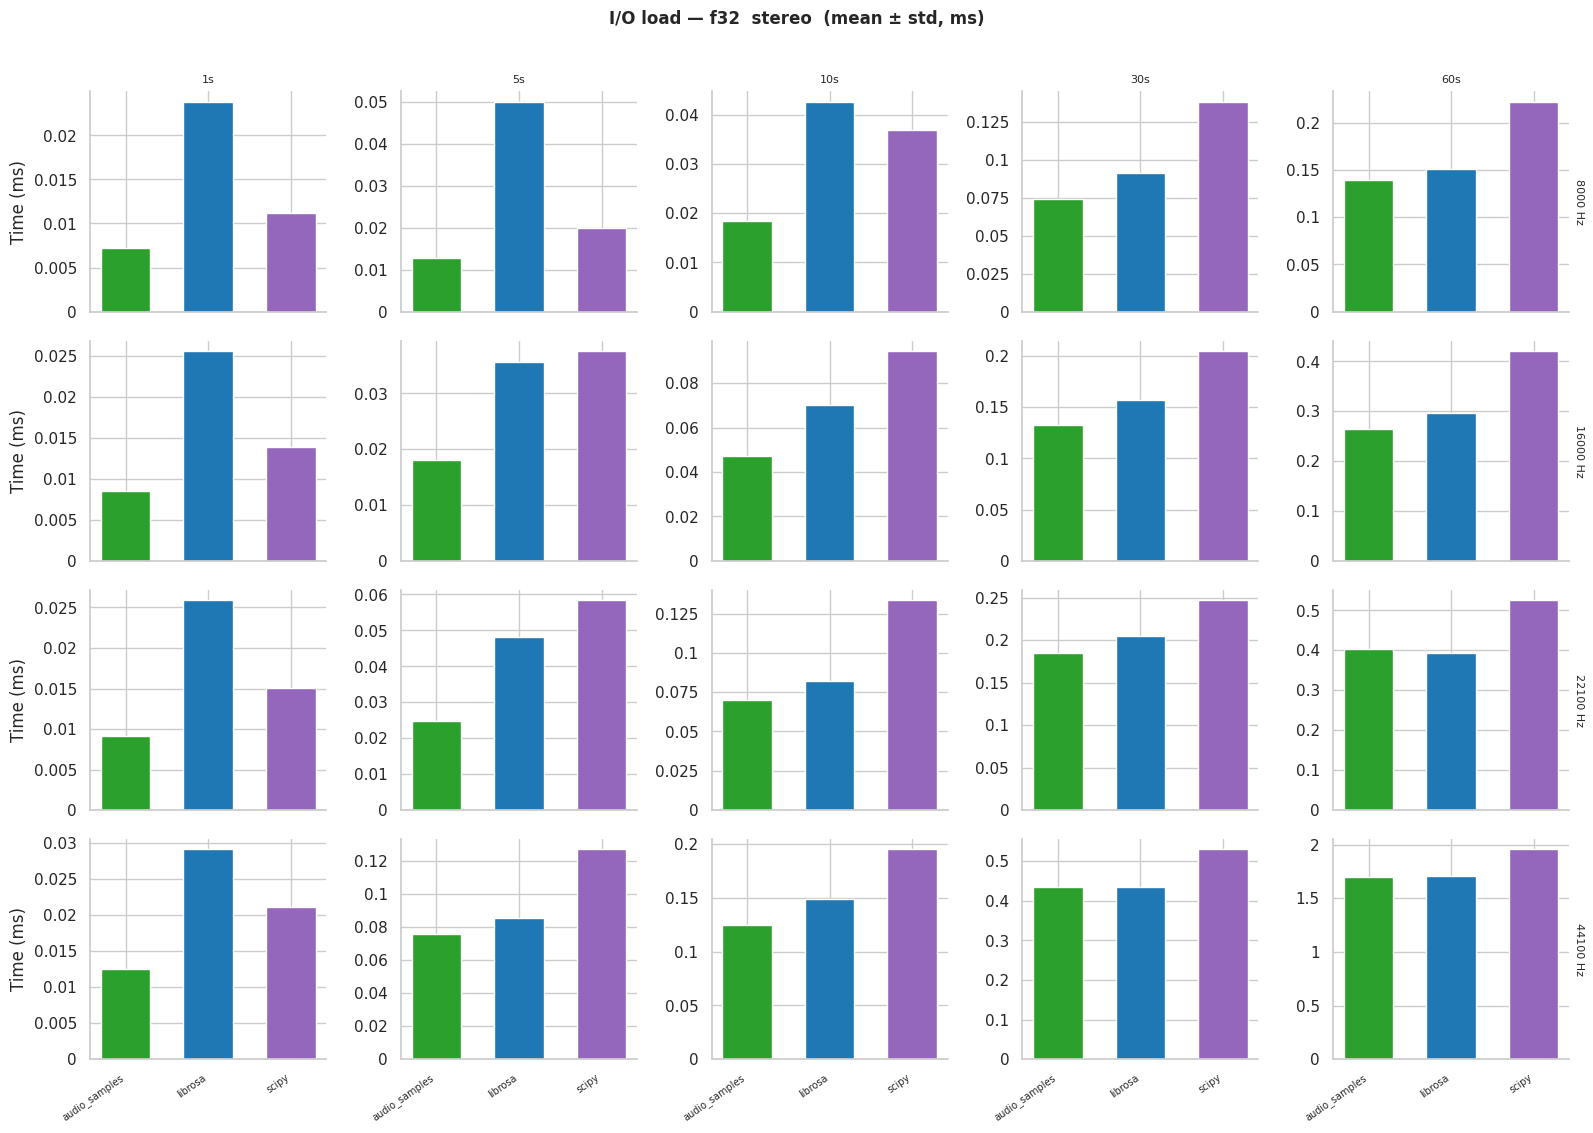

In [4]:
for dtype in ["i16", "f32"]:
    for channels in [1, 2]:
        plot_io_bars(dtype, channels, "load")

## Save times

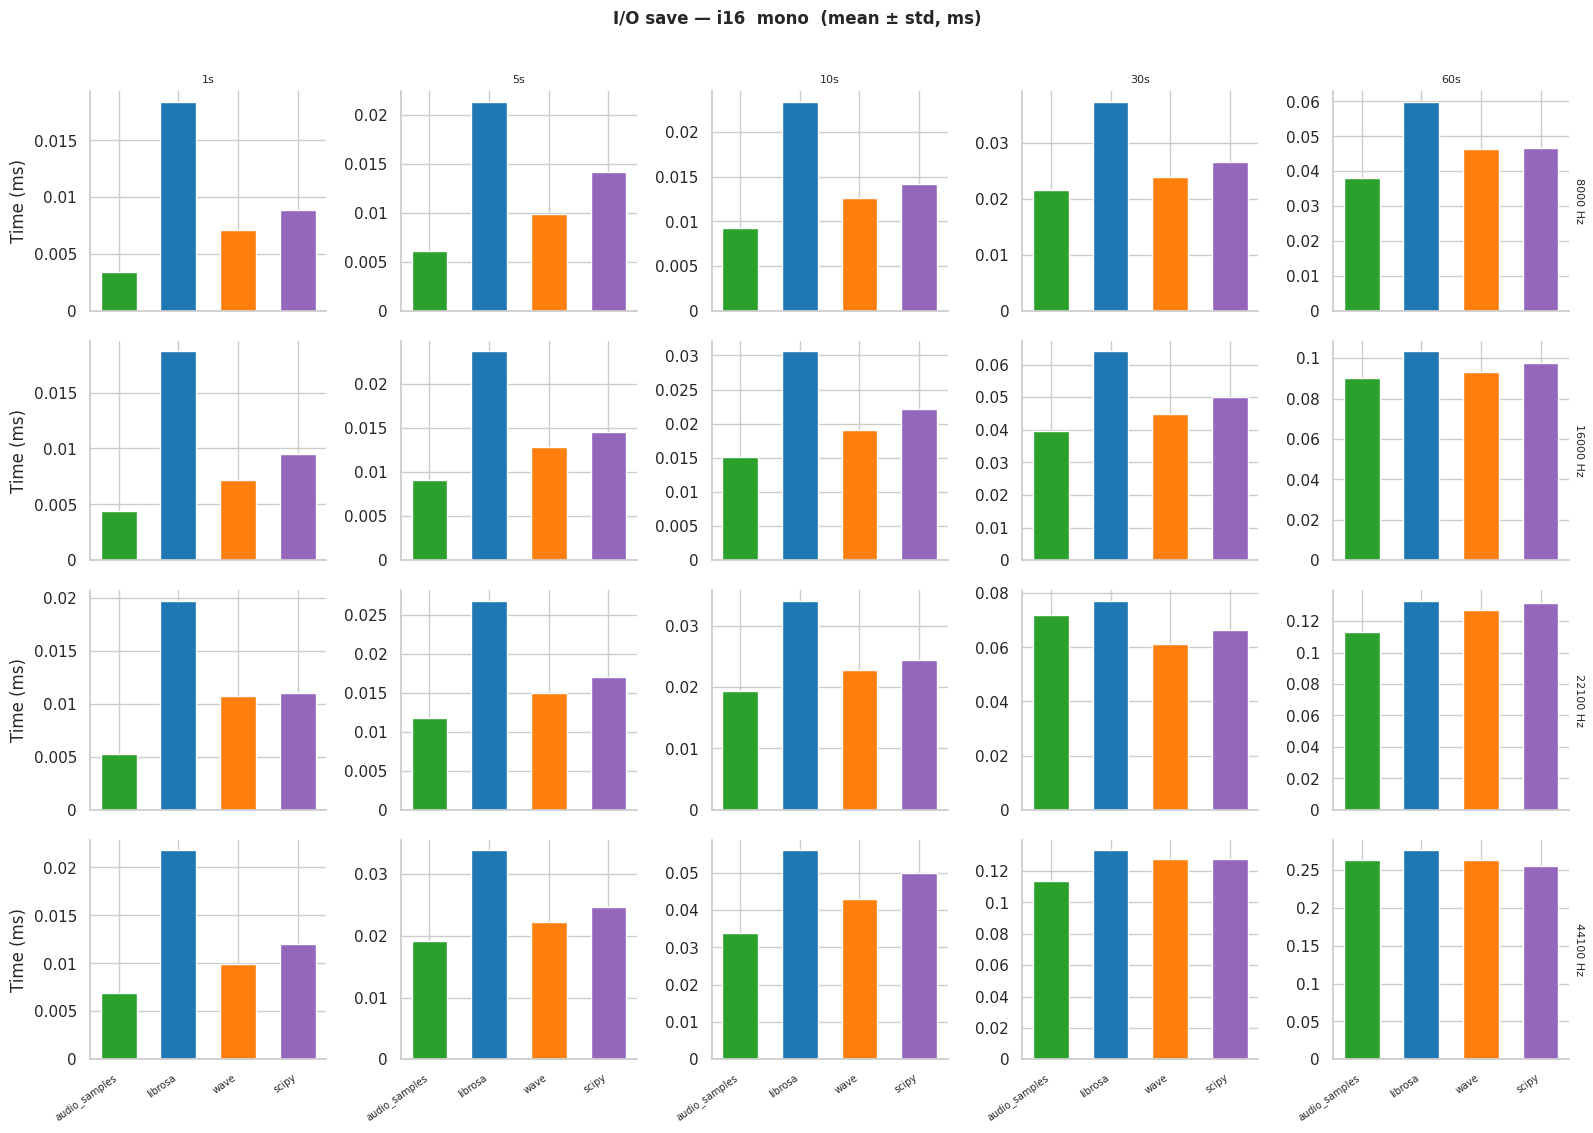

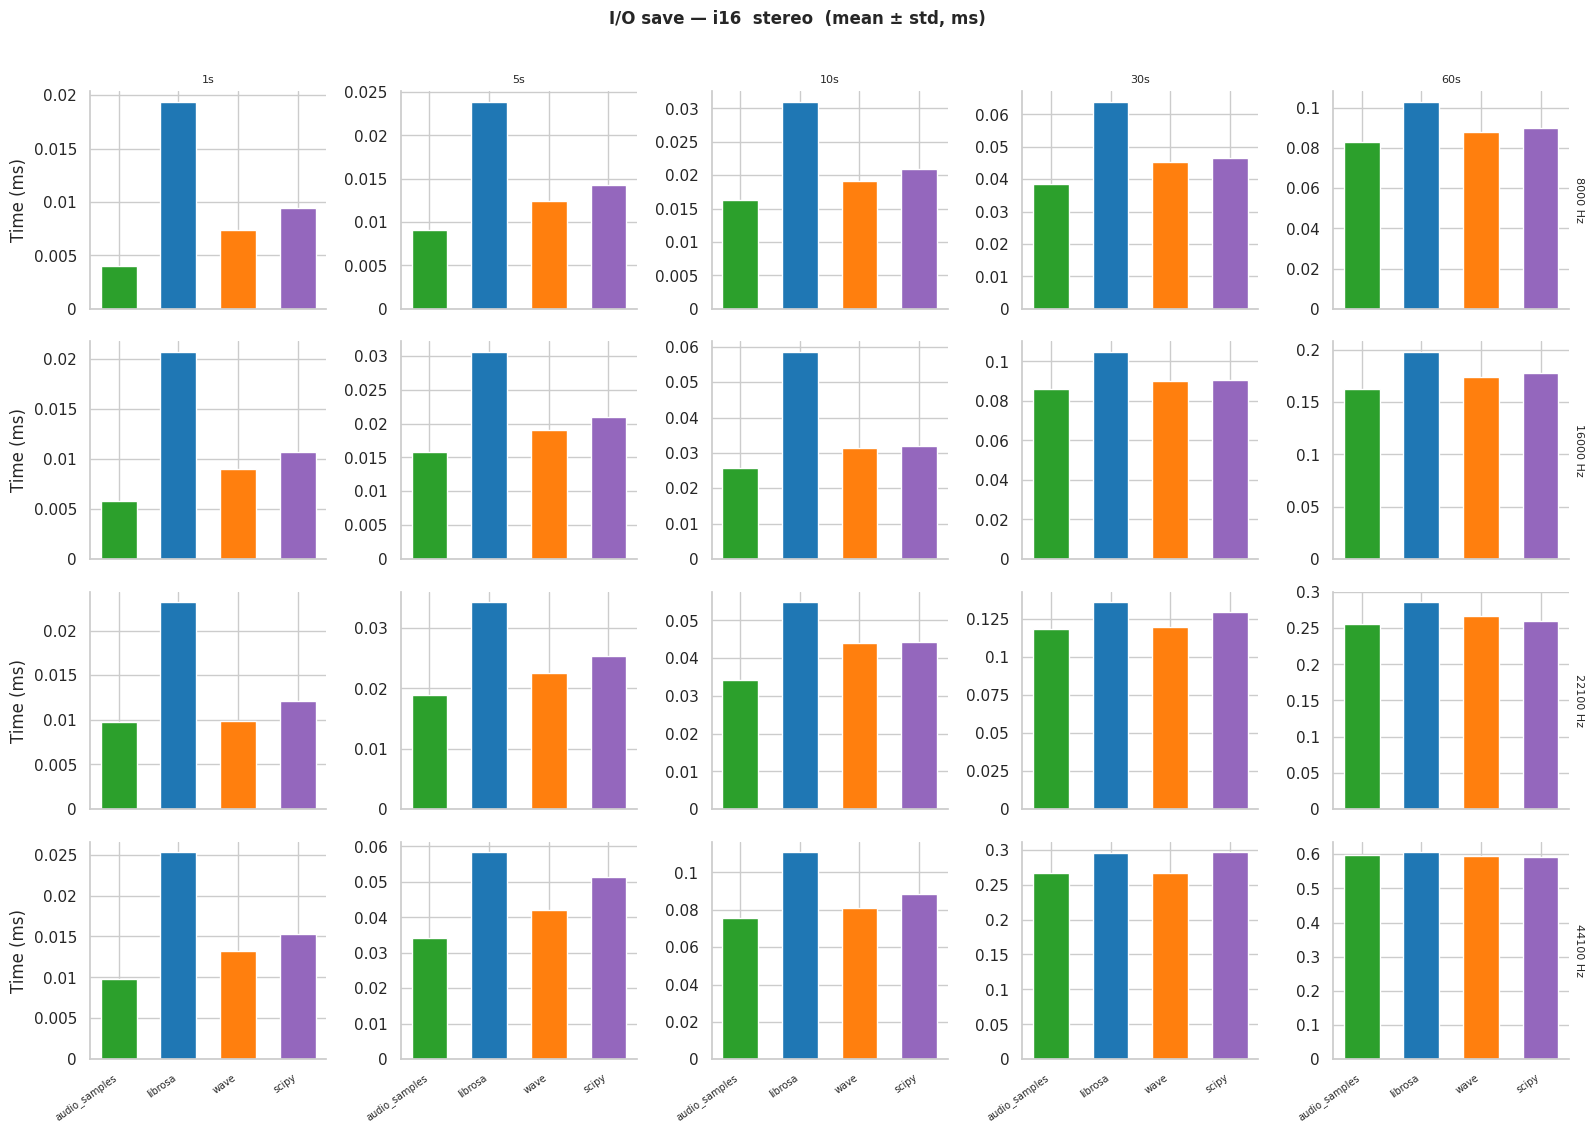

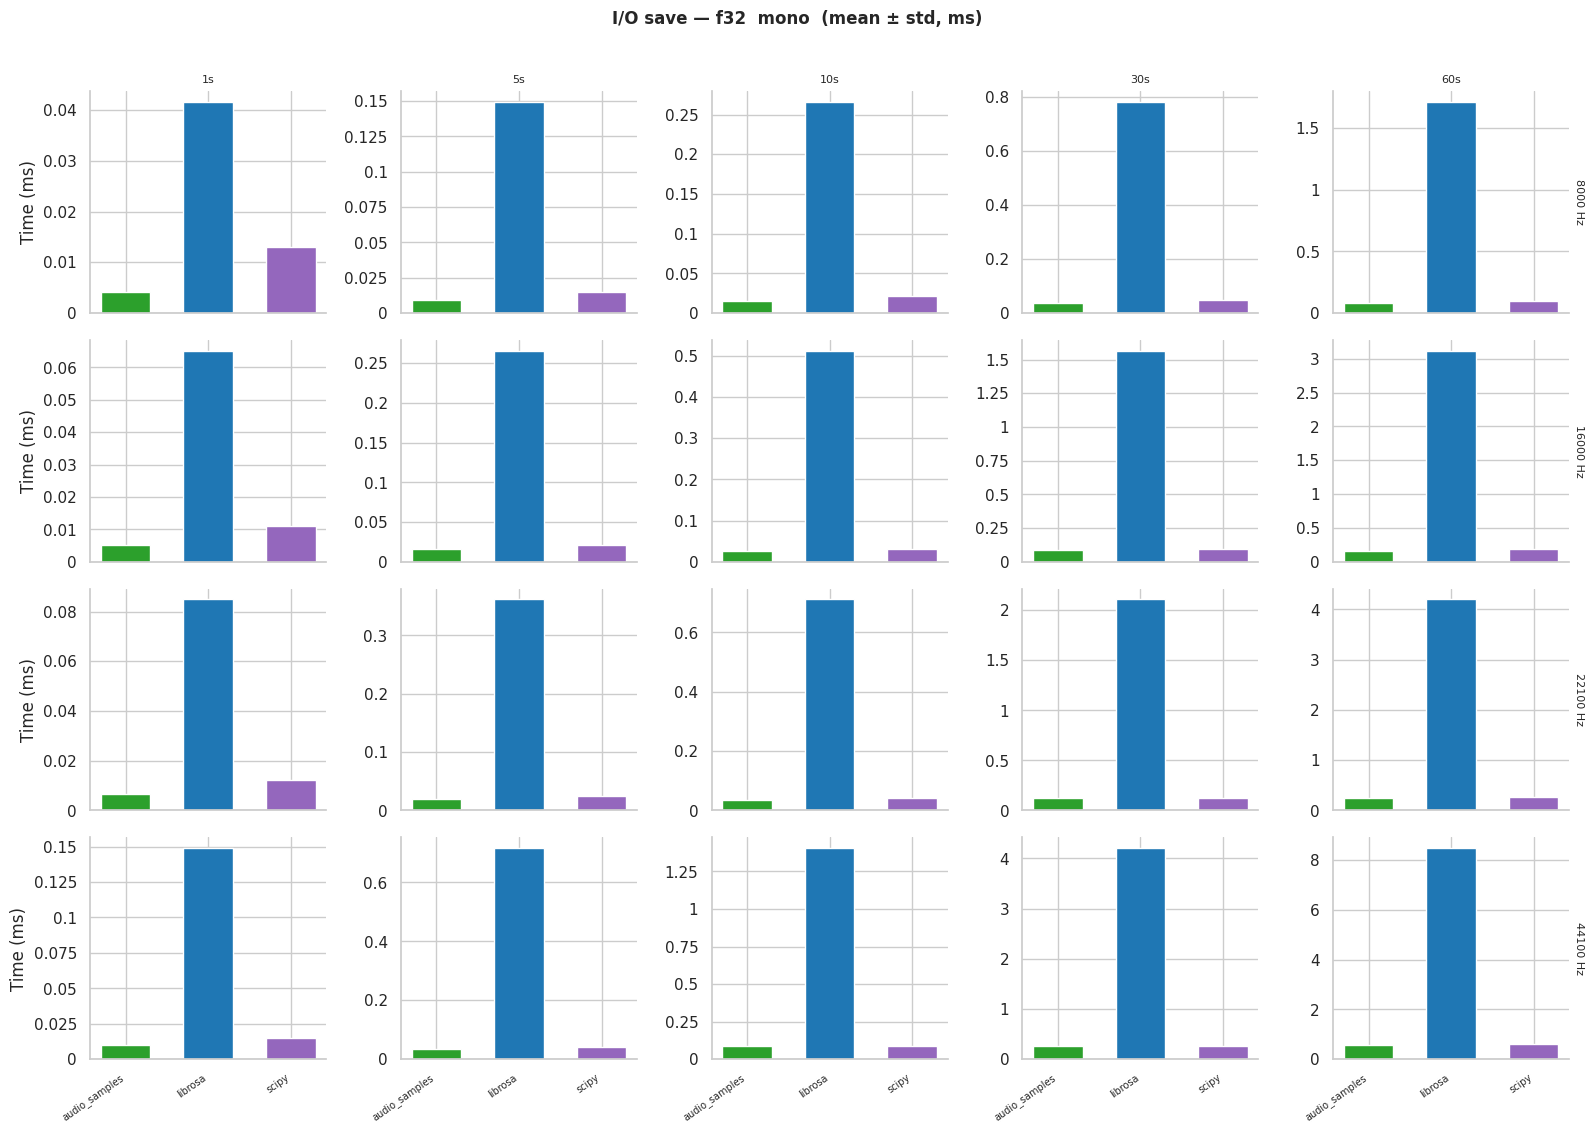

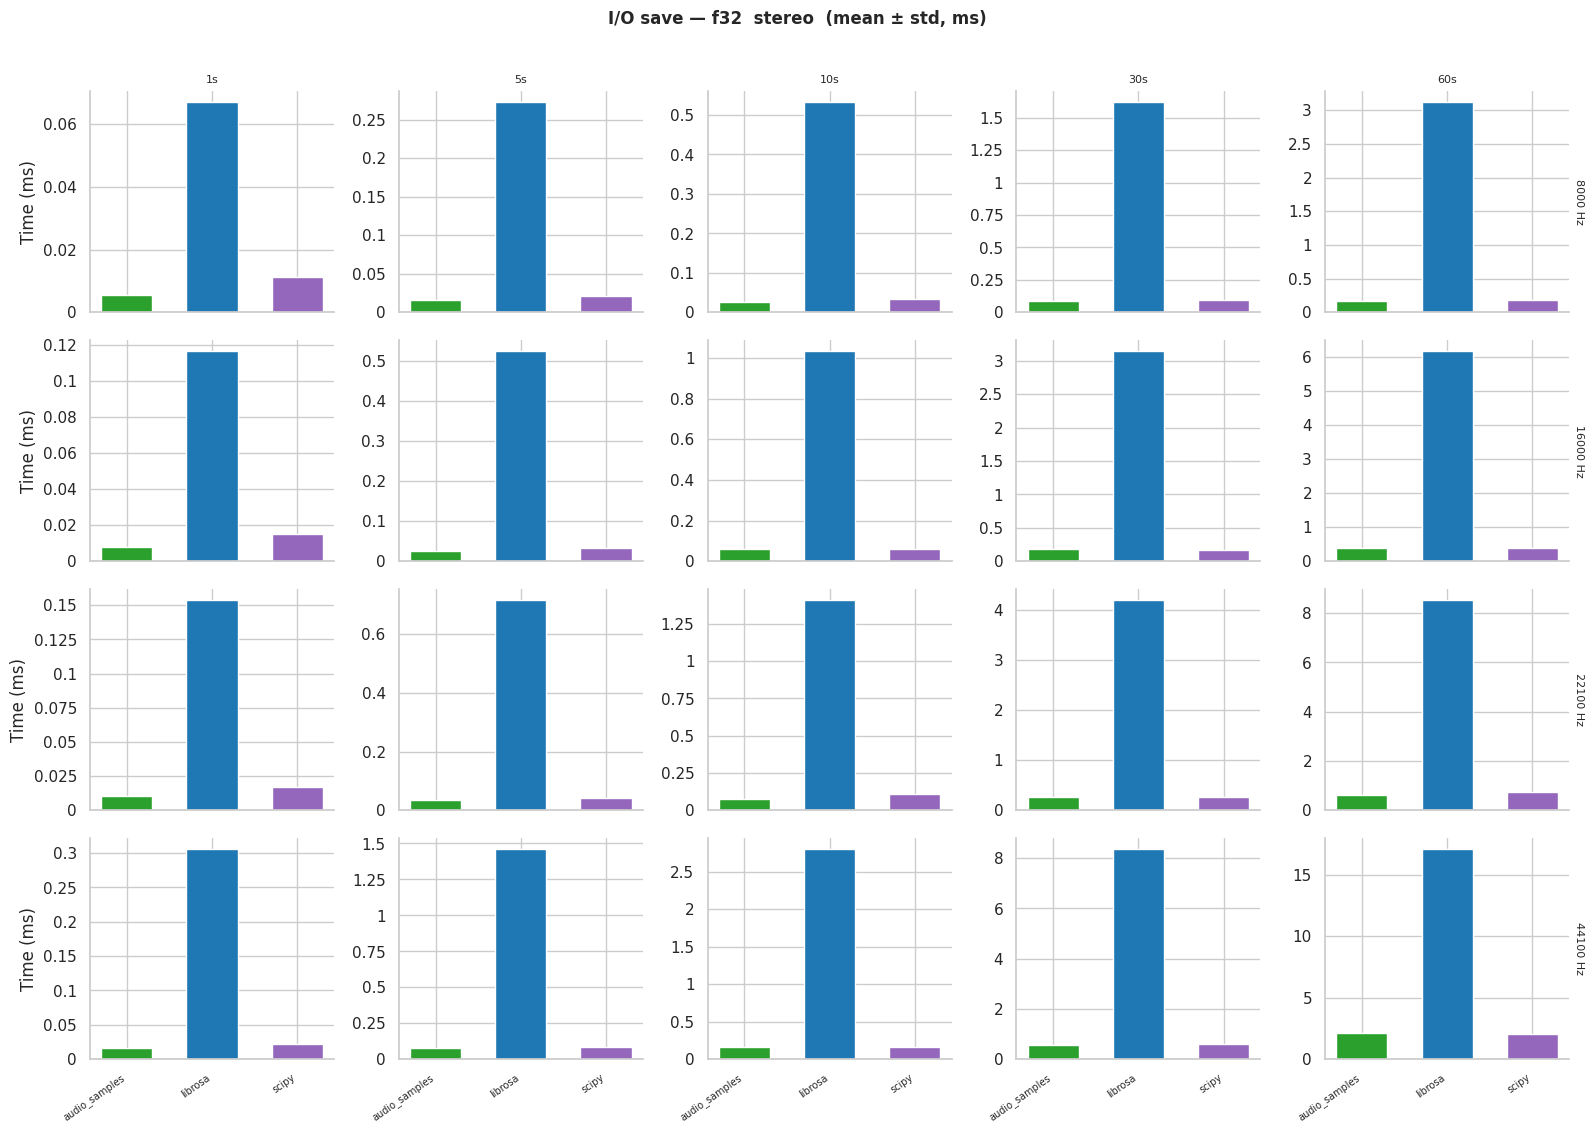

In [5]:
for dtype in ["i16", "f32"]:
    for channels in [1, 2]:
        plot_io_bars(dtype, channels, "save")

In [6]:
from librosa import load
data, sr = load("audio.wav")
duration = data.shape[1] / sr
channels = data.shape[0] 



/tmp/ipykernel_52532/2919942997.py:2: UserWarning: PySoundFile failed. Trying audioread instead.
  data, sr = load("audio.wav")
/home/jmg/code/audio/audio_samples_python/.venv/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


FileNotFoundError: [Errno 2] No such file or directory: 'audio.wav'

In [ ]:
import audio_samples as aus

audio = aus.io.read("audio.wav")
duration = audio.duration_seconds
channels = audio.num_channels

## Speedup over audio_samples (load)

How many times faster/slower each library is relative to `audio_samples` for the load operation.  
Values > 1 mean `audio_samples` is faster; values < 1 mean the other library is faster.

In [ ]:
def plot_speedup(operation: str) -> None:
    col = "mean_ms"
    key_cols = ["sample_rate", "dtype", "duration", "channels"]

    op_df = df_long[df_long["operation"] == operation].copy()
    base = (
        op_df[op_df["lib"] == "audio_samples"]
        .set_index(key_cols)[col]
        .rename("base_ms")
    )
    merged = op_df.join(base, on=key_cols)
    merged["speedup"] = merged["base_ms"] / merged["mean_ms"]
    others = merged[
        (merged["lib"] != "audio_samples") & (merged["lib"] != "torchaudio")
    ].copy()
    others["channels_label"] = others["channels"].map({1: "mono", 2: "stereo"})
    others["config"] = (
        others["dtype"] + " " + others["channels_label"]
        + "\n" + others["sample_rate"].astype(str) + "Hz "
        + others["duration"].astype(int).astype(str) + "s"
    )

    g = sns.FacetGrid(
        others,
        col="lib", col_order=[l for l in LIB_ORDER if l not in ("audio_samples", "torchaudio")],
        height=4, aspect=0.9,
        sharey=True,
    )
    g.map_dataframe(
        sns.barplot,
        x="config", y="speedup",
        order=sorted(others["config"].unique()),
        palette="coolwarm_r",
        errorbar=None,
    )
    for ax in g.axes.flat:
        ax.axhline(1.0, color="black", linewidth=1.0, linestyle="--", label="parity")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=5.5)
        ax.set_ylabel("audio_samples time / library time  (>1 = aus faster)")
    g.set_titles("{col_name}", size=9)
    g.figure.suptitle(
        f"Relative {operation} speed vs audio_samples  (higher = aus faster)",
        fontsize=12, fontweight="bold", y=1.01,
    )
    g.figure.tight_layout()
    plt.show()

plot_speedup("load")

In [ ]:
plot_speedup("save")